In [1]:
%cd nanoVLM
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

import models.config as config
from models.vision_language_model_action import VisionLanguageActionModel
from minigrid.envs.empty import EmptyEnv
from data.processors import get_image_processor, get_image_string
from data.emptyenv_action_dataset import DEFAULT_PROMPT

ID2ACTION = {0: "left", 1: "right", 2: "forward"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# общий конфиг (одинаковый для всех прогонов)
vlm_cfg = config.VLMConfig()
vlm_cfg.max_img_size = 512

# общий image_processor (одинаковый для всех прогонов)
image_processor = get_image_processor(
    vlm_cfg.max_img_size,
    vlm_cfg.vit_img_size,
    vlm_cfg.resize_to_max_side_len
)

@torch.no_grad()
def policy_action_from_rgb(model, rgb, prompt=DEFAULT_PROMPT, temperature=1.0, greedy=False):
    """
    temperature > 1.0  -> more exploration
    temperature < 1.0  -> more greedy
    greedy=True        -> argmax regardless of temperature
    """
    tokenizer = model.tokenizer
    device = next(model.parameters()).device

    img = Image.fromarray(rgb).convert("RGB")
    processed_image, splitted_image_count = image_processor(img)

    messages = [{"role": "user", "content": prompt}]
    image_string = get_image_string(tokenizer, [splitted_image_count], vlm_cfg.mp_image_token_length)
    messages[0]["content"] = image_string + messages[0]["content"]

    conv = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_special_tokens=False,
        return_dict=True,
    )

    input_ids = torch.tensor(conv["input_ids"], dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = torch.tensor(conv["attention_mask"], dtype=torch.long).unsqueeze(0).to(device)
    images = [[processed_image]]  # batch size 1

    logits, _ = model(
        input_ids=input_ids,
        images=images,
        attention_mask=attention_mask,
        action_labels=None
    )  # logits: [1, 3]
    logits = logits[0]  # [3]

    if greedy:
        probs = torch.softmax(logits, dim=-1)
        action = int(torch.argmax(probs).item())
        return action, probs.detach().cpu().numpy()

    T = float(temperature)
    if T <= 0:
        raise ValueError("temperature must be > 0")

    probs = torch.softmax(logits / T, dim=-1)
    action = int(torch.multinomial(probs, num_samples=1).item())
    return action, probs.detach().cpu().numpy()


def run_eval(model, num_episodes=20, sizes=[6, 7], max_steps=200, seed=0,
             temperature=1.0, greedy=False, render=False):
    successes = 0
    returns = []
    lengths = []

    rng = np.random.default_rng(seed)

    for ep in range(num_episodes):
        size = int(rng.choice(sizes))
        env = EmptyEnv(size=size, agent_start_pos=None, render_mode="rgb_array")
        obs, info = env.reset(seed=seed + ep)

        env.agent_dir = int(rng.integers(0, 4))

        ep_ret = 0.0
        ep_len = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            rgb = env.render()

            action, probs = policy_action_from_rgb(
                model,
                rgb,
                temperature=temperature,
                greedy=greedy
            )

            obs, reward, terminated, truncated, info = env.step(action)
            ep_ret += float(reward)
            ep_len += 1

            if render:
                print(f"ep={ep} t={ep_len} a={ID2ACTION[action]} probs={np.round(probs,3)}")

            if ep_len >= max_steps:
                break

        success = 1 if ep_ret > 0 else 0
        successes += success
        returns.append(ep_ret)
        lengths.append(ep_len)

        print(f"[EP {ep}] size={size} success={success} return={ep_ret:.2f} len={ep_len}")

        env.close()

    metrics = {
        "success_rate": successes / num_episodes,
        "avg_return": float(np.mean(returns)),
        "avg_length": float(np.mean(lengths)),
    }
    return metrics


def load_model_for_step(step, base_ckpt_dir, grpo_check = False):
    """
    step=None -> необученная модель
    иначе грузим чекпоинт step_{step}
    """
    if step is None:
        model = VisionLanguageActionModel(vlm_cfg, load_backbone=True, num_actions=3)
    elif grpo_check:
        ckpt_path = os.path.join(base_ckpt_dir, f"it_{step}")
        model = VisionLanguageActionModel.from_pretrained(ckpt_path)        
    else:
        ckpt_path = os.path.join(base_ckpt_dir, f"step_{step}")
        model = VisionLanguageActionModel.from_pretrained(ckpt_path)

    model.to(device)
    model.eval()
    return model




# ==== основной прогон ====

# если хотим прогнать eval по grpo
grpo = True 

base_ckpt_dir = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/base_sft"
steps = [None, 44, 88, 132, 176]   # шаги для eval base sft 

base_ckpt_dir_grpo = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/grpo"

if grpo:
    sft_base_step = 200
    # None должен быть для sft base
    steps = [None, 2, 4, 6, 8] 

results = {}

common_eval_kwargs = dict(
    num_episodes=50,
    sizes=[10],
    max_steps=100,
    seed=123,
    temperature=1.4,
    greedy=False,
    render=False
)

for step in steps:
    if grpo and step is None:
        model = load_model_for_step(sft_base_step, base_ckpt_dir)
        print('sft base for grpo loaded')
    elif grpo: 
        model = load_model_for_step(step, base_ckpt_dir_grpo, grpo_check = True)
        print(f'grpo checkpoint {step} loaded')
    else:
        model = load_model_for_step(step, base_ckpt_dir)
        print(f'sft checkpoint loaded {step}')
    metrics = run_eval(model, **common_eval_kwargs)

    key = 0 if step is None else step
    results[key] = metrics

    print(f"\n=== step={key} ===")
    print(f"Success rate: {metrics['success_rate']:.3f}")
    print(f"Avg return:   {metrics['avg_return']:.3f}")
    print(f"Avg length:   {metrics['avg_length']:.1f}")


    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

/teamspace/studios/this_studio/nanoVLM-action/nanoVLM


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Resize to max side len: True
sft base for grpo loaded
[EP 0] size=10 success=1 return=0.82 len=79
[EP 1] size=10 success=1 return=0.91 len=39
[EP 2] size=10 success=0 return=0.00 len=100
[EP 3] size=10 success=1 return=0.85 len=66
[EP 4] size=10 success=1 return=0.97 len=14
[EP 5] size=10 success=1 return=0.99 len=4
[EP 6] size=10 success=1 return=0.81 len=85
[EP 7] size=10 success=1 return=0.86 len=60
[EP 8] size=10 success=0 return=0.00 len=100
[EP 9] size=10 success=1 return=0.98 len=9
[EP 10] size=10 success=0 return=0.00 len=100
[EP 11] size=10 success=1 return=0.94 len=28
[EP 12] size=10 success=1 return=0.90 len=44
[EP 13] size=10 success=1 return=0.87 len=56
[EP 14] size=10 success=1 return=0.97 len=15
[EP 15] size=10 success=1 return=0.93 len=31
[EP 16] size=10 success=1 return=0.96 len=16
[EP 17] size=10 success=0 return=0.00 len=100
[EP 18] size=10 success=1 return=0.98 len=9
[EP 19] size=10 success=1 return=0.96 len=18
[EP 20] size=10 success=1 return=0.97 len=15
[EP 21] si

In [ ]:
base_ckpt_dir = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/base_sft/step_132"
base_ckpt_dir_grpo = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/grpo/it_2"




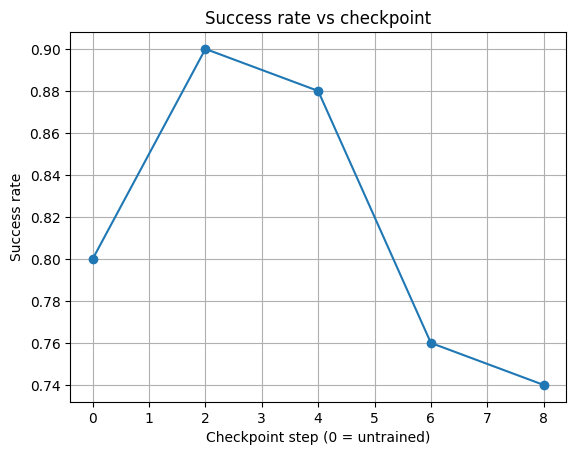

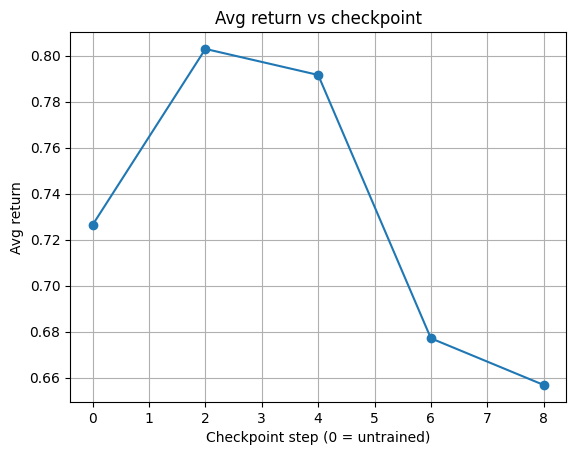

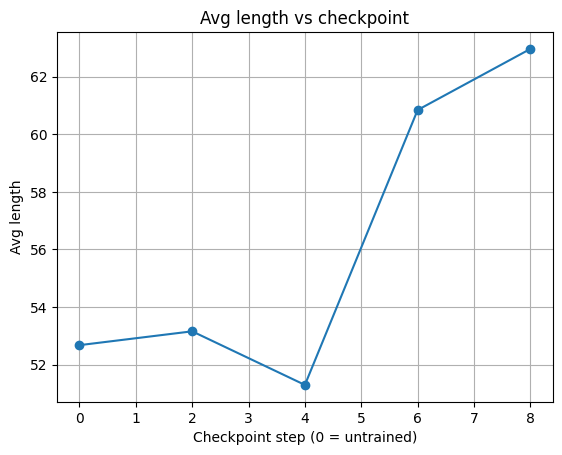

In [2]:
# grpo small_sizes + label smooth 

xs = sorted(results.keys())
succ = [results[x]["success_rate"] for x in xs]
ret  = [results[x]["avg_return"] for x in xs]
leng = [results[x]["avg_length"] for x in xs]

plt.figure()
plt.plot(xs, succ, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Success rate")
plt.title("Success rate vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, ret, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg return")
plt.title("Avg return vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, leng, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg length")
plt.title("Avg length vs checkpoint")
plt.grid(True)
plt.show()

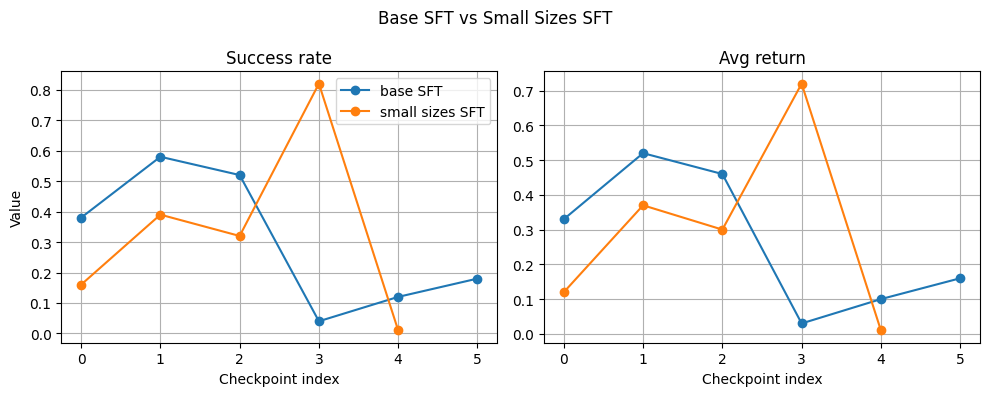

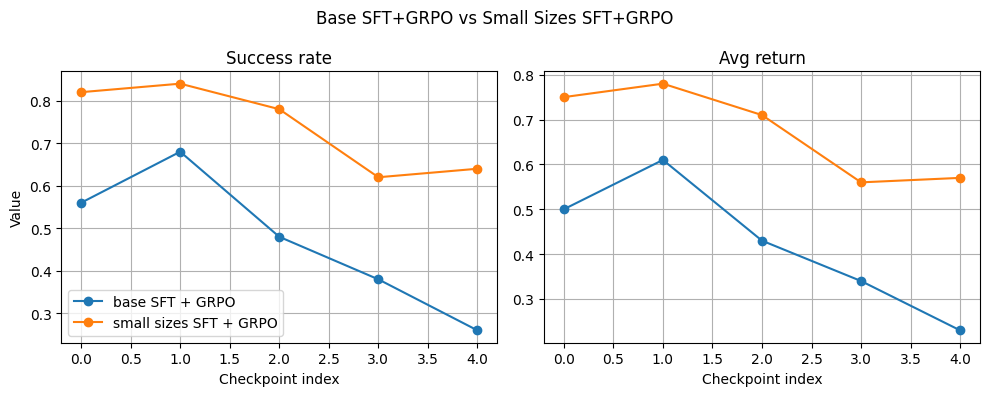

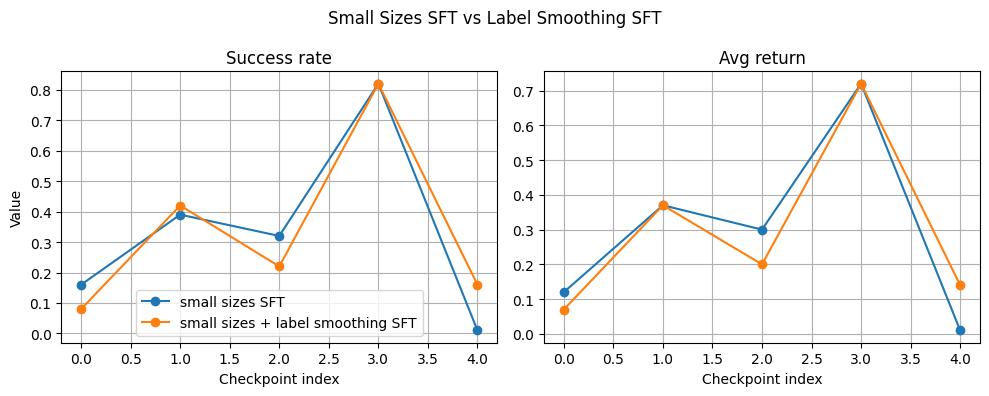

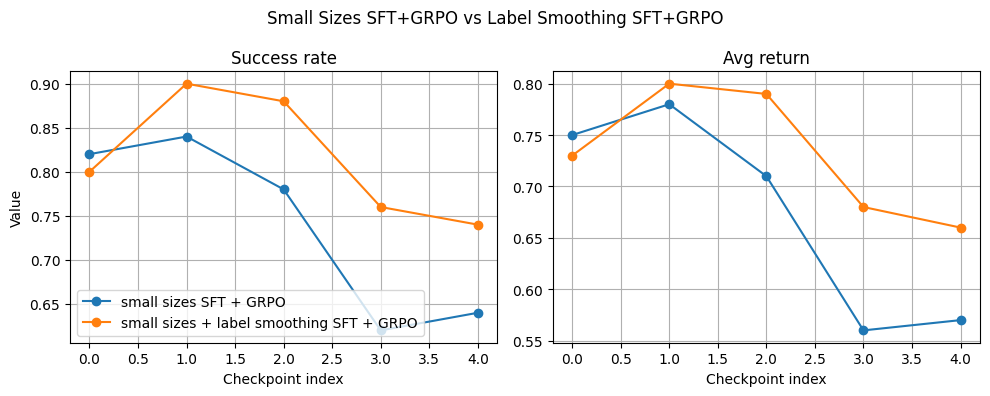

In [20]:
import matplotlib.pyplot as plt

def plot_compare(data1, data2, label1, label2, title):

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    metrics = [
        ("success", "Success rate"),
        ("return", "Avg return"),
    ]

    for ax, (key, name) in zip(axes, metrics):

        ax.plot(range(len(data1[key])), data1[key], marker='o', label=label1)
        ax.plot(range(len(data2[key])), data2[key], marker='o', label=label2)

        ax.set_title(name)
        ax.set_xlabel("Checkpoint index")
        ax.grid(True)

    axes[0].set_ylabel("Value")
    axes[0].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# DATA
# -----------------------------

base_sft = {
    "success":[0.38,0.58,0.52,0.04,0.12,0.18],
    "return":[0.33,0.52,0.46,0.03,0.10,0.16],
    "len":[84,68,73,99,95,92]
}

base_grpo = {
    "success":[0.56,0.68,0.48,0.38,0.26],
    "return":[0.50,0.61,0.43,0.34,0.23],
    "len":[69,62,74,81,87]
}

small_sft = {
    "success":[0.16,0.39,0.32,0.82,0.01],
    "return":[0.12,0.37,0.3,0.72,0.01],
    "len":[96,81,87,94,10]
}

small_grpo = {
    "success":[0.82,0.84,0.78,0.62,0.64],
    "return":[0.75,0.78,0.71,0.56,0.57],
    "len":[49,44,54,67,68]
}

ls_sft = {
    "success":[0.08,0.42,0.22,0.82,0.16],
    "return":[0.07,0.37,0.20,0.72,0.14],
    "len":[96,81,87,60,94]
}

ls_grpo = {
    "success":[0.80,0.90,0.88,0.76,0.74],
    "return":[0.73,0.80,0.79,0.68,0.66],
    "len":[53,53,51,61,63]
}

# -----------------------------
# 1
# base SFT vs small sizes SFT
# -----------------------------
plot_compare(
    base_sft,
    small_sft,
    "base SFT",
    "small sizes SFT",
    "Base SFT vs Small Sizes SFT"
)

# -----------------------------
# 2
# base SFT + GRPO vs small sizes SFT + GRPO
# -----------------------------
plot_compare(
    base_grpo,
    small_grpo,
    "base SFT + GRPO",
    "small sizes SFT + GRPO",
    "Base SFT+GRPO vs Small Sizes SFT+GRPO"
)

# -----------------------------
# 3
# small sizes SFT vs label smoothing SFT
# -----------------------------
plot_compare(
    small_sft,
    ls_sft,
    "small sizes SFT",
    "small sizes + label smoothing SFT",
    "Small Sizes SFT vs Label Smoothing SFT"
)

# -----------------------------
# 4
# small sizes SFT+GRPO vs label smoothing SFT+GRPO
# -----------------------------
plot_compare(
    small_grpo,
    ls_grpo,
    "small sizes SFT + GRPO",
    "small sizes + label smoothing SFT + GRPO",
    "Small Sizes SFT+GRPO vs Label Smoothing SFT+GRPO"
)

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4]

avg_return = [0.16, 0.208, 0.107, 0.115]
success_rate = [0.188, 0.249, 0.125, 0.125]
avg_length = [89.6, 86.8, 92.8, 90.6]


# Average return
plt.figure()
plt.plot(epochs, avg_return, marker='o')
plt.title("GRPO (text + action): Average return vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Average return")
plt.grid(True)
plt.show()


# Success rate
plt.figure()
plt.plot(epochs, success_rate, marker='o')
plt.title("GRPO (text + action): Success rate vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Success rate")
plt.grid(True)
plt.show()


# Average length
plt.figure()
plt.plot(epochs, avg_length, marker='o')
plt.title("GRPO (text + action): Average length vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Average length")
plt.grid(True)
plt.show()

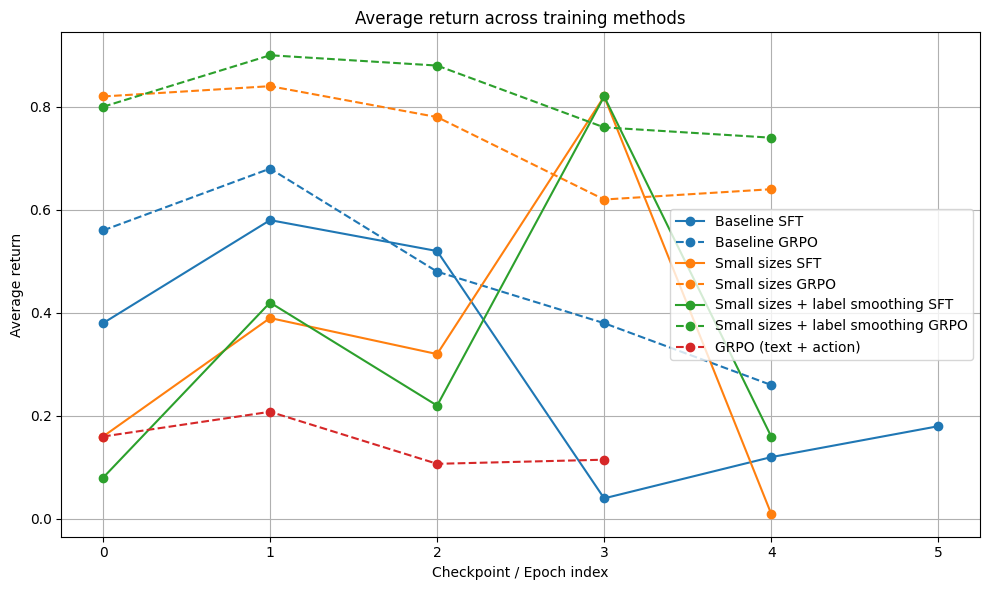

In [21]:
import matplotlib.pyplot as plt

# Average return
metric = 'success'

base_sft = base_sft[metric]
base_grpo = base_grpo[metric]

small_sft = small_sft[metric]
small_grpo = small_grpo[metric]

small_ls_sft = ls_sft[metric]
small_ls_grpo = ls_grpo[metric]

grpo_text_action = [0.16, 0.208, 0.107, 0.115]

plt.figure(figsize=(10,6))

# baseline
plt.plot(range(len(base_sft)), base_sft,
         color="tab:blue", linestyle="-", marker="o",
         label="Baseline SFT")

plt.plot(range(len(base_grpo)), base_grpo,
         color="tab:blue", linestyle="--", marker="o",
         label="Baseline GRPO")

# small sizes
plt.plot(range(len(small_sft)), small_sft,
         color="tab:orange", linestyle="-", marker="o",
         label="Small sizes SFT")

plt.plot(range(len(small_grpo)), small_grpo,
         color="tab:orange", linestyle="--", marker="o",
         label="Small sizes GRPO")

# label smoothing
plt.plot(range(len(small_ls_sft)), small_ls_sft,
         color="tab:green", linestyle="-", marker="o",
         label="Small sizes + label smoothing SFT")

plt.plot(range(len(small_ls_grpo)), small_ls_grpo,
         color="tab:green", linestyle="--", marker="o",
         label="Small sizes + label smoothing GRPO")

# text + action
plt.plot(range(len(grpo_text_action)), grpo_text_action,
         color="tab:red", linestyle="--", marker="o",
         label="GRPO (text + action)")

plt.title("Average return across training methods")
plt.xlabel("Checkpoint / Epoch index")
plt.ylabel("Average return")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()